In [2]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from PIL import Image, ImageFile
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

ImageFile.LOAD_TRUNCATED_IMAGES = True

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)
print("GPU :", torch.cuda.get_device_name(0) if device.type == "cuda" else "CPU")

Device : cuda
GPU : NVIDIA GeForce RTX 4060 Ti


In [3]:
def rgb_loader(path):
    """Charge chaque image en RGB, y compris les images palette/transparence."""
    with Image.open(path) as image:
        if image.mode == "P" and "transparency" in image.info:
            image = image.convert("RGBA")
        return image.convert("RGB")


current_dir = Path.cwd().resolve()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

data_root = Path(r"D:\datasets\waste-classifier\extracted\dataset_splits")
train_dir = data_root / "train"
test_dir = data_root / "test"

models_dir = project_root / "outputs" / "models"
metrics_dir = project_root / "outputs" / "metrics"
figures_dir = project_root / "outputs" / "figures"

for folder in [models_dir, metrics_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

# Transformations adaptées à un modèle pré-entraîné ImageNet
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

full_train_dataset = ImageFolder(
    train_dir,
    transform=train_transform,
    loader=rgb_loader
)

full_train_dataset_eval = ImageFolder(
    train_dir,
    transform=eval_transform,
    loader=rgb_loader
)

test_dataset = ImageFolder(
    test_dir,
    transform=eval_transform,
    loader=rgb_loader
)

class_names = full_train_dataset.classes
num_classes = len(class_names)

all_indices = list(range(len(full_train_dataset)))
all_labels = full_train_dataset.targets

train_indices, val_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SEED,
    stratify=all_labels
)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset = Subset(full_train_dataset_eval, val_indices)

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

# Poids pour gérer le déséquilibre des classes
train_labels = [full_train_dataset.targets[index] for index in train_indices]
class_counts = np.bincount(train_labels, minlength=num_classes)

class_weights = len(train_labels) / (num_classes * class_counts)
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("Classes :", class_names)
print("Train :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test :", len(test_dataset))

Classes : ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
Train : 2088
Validation : 523
Test : 644


In [4]:
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

# Gèle toutes les couches pré-entraînées
for parameter in model.parameters():
    parameter.requires_grad = False

# Remplace la dernière couche pour nos 7 catégories
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model.fc)
print(f"Paramètres entraînables : {trainable_parameters:,}")

Linear(in_features=512, out_features=7, bias=True)
Paramètres entraînables : 3,591


In [5]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)


def evaluate_model(model, loader):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            predictions = outputs.argmax(dim=1)

            total_loss += loss.item() * images.size(0)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            true_labels.extend(labels.cpu().numpy())
            predicted_labels.extend(predictions.cpu().numpy())

    return {
        "loss": total_loss / total,
        "accuracy": correct / total,
        "macro_f1": f1_score(
            true_labels,
            predicted_labels,
            average="macro",
            zero_division=0
        )
    }


def train_model(
    model,
    optimizer,
    num_epochs,
    patience,
    model_path,
    phase_name,
    keep_backbone_frozen=False
):
    history = {
        "phase": [],
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": []
    }

    best_val_f1 = -1.0
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, num_epochs + 1):
        model.train()

        # Pendant la phase gelée, les BatchNorm du backbone restent en mode évaluation
        if keep_backbone_frozen:
            for module in list(model.children())[:-1]:
                module.eval()

        running_loss = 0.0
        correct = 0
        total = 0

        progress_bar = tqdm(
            train_loader,
            desc=f"{phase_name} — Epoch {epoch}/{num_epochs}"
        )

        for images, labels in progress_bar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            predictions = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            progress_bar.set_postfix(loss=f"{loss.item():.4f}")

        train_loss = running_loss / total
        train_accuracy = correct / total

        validation_results = evaluate_model(model, val_loader)

        history["phase"].append(phase_name)
        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(validation_results["loss"])
        history["val_accuracy"].append(validation_results["accuracy"])
        history["val_macro_f1"].append(validation_results["macro_f1"])

        print(
            f"\n{phase_name} | Epoch {epoch}/{num_epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_accuracy:.4f} | "
            f"Val loss: {validation_results['loss']:.4f} | "
            f"Val acc: {validation_results['accuracy']:.4f} | "
            f"Val macro F1: {validation_results['macro_f1']:.4f}"
        )

        if validation_results["macro_f1"] > best_val_f1:
            best_val_f1 = validation_results["macro_f1"]
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "class_names": class_names,
                    "best_val_macro_f1": best_val_f1,
                    "best_epoch": best_epoch,
                    "phase": phase_name
                },
                model_path
            )

            print(f"✓ Meilleur modèle sauvegardé : {model_path.name}")

        else:
            epochs_without_improvement += 1
            print(f"Aucune amélioration ({epochs_without_improvement}/{patience})")

        if epochs_without_improvement >= patience:
            print("Arrêt anticipé déclenché.")
            break

    return pd.DataFrame(history), best_val_f1, best_epoch

In [5]:
optimizer_frozen = torch.optim.AdamW(
    model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

resnet_frozen_path = models_dir / "resnet18_frozen_best.pt"

history_frozen, best_f1_frozen, best_epoch_frozen = train_model(
    model=model,
    optimizer=optimizer_frozen,
    num_epochs=10,
    patience=4,
    model_path=resnet_frozen_path,
    phase_name="ResNet18 frozen",
    keep_backbone_frozen=True
)

print("\nRésultat phase gelée")
print("Meilleur macro F1 validation :", round(best_f1_frozen, 4))
print("Meilleure époque :", best_epoch_frozen)

ResNet18 frozen — Epoch 1/10:   0%|          | 0/66 [00:00<?, ?it/s]


ResNet18 frozen | Epoch 1/10 | Train loss: 1.2888 | Train acc: 0.5876 | Val loss: 0.8089 | Val acc: 0.7533 | Val macro F1: 0.7220
✓ Meilleur modèle sauvegardé : resnet18_frozen_best.pt


ResNet18 frozen — Epoch 2/10:   0%|          | 0/66 [00:00<?, ?it/s]


ResNet18 frozen | Epoch 2/10 | Train loss: 0.7374 | Train acc: 0.7787 | Val loss: 0.6828 | Val acc: 0.7514 | Val macro F1: 0.7336
✓ Meilleur modèle sauvegardé : resnet18_frozen_best.pt


ResNet18 frozen — Epoch 3/10:   0%|          | 0/66 [00:00<?, ?it/s]

...


ResNet18 frozen | Epoch 8/10 | Train loss: 0.3930 | Train acc: 0.8664 | Val loss: 0.4393 | Val acc: 0.8451 | Val macro F1: 0.8363
✓ Meilleur modèle sauvegardé : resnet18_frozen_best.pt


ResNet18 frozen — Epoch 9/10:   0%|          | 0/66 [00:00<?, ?it/s]


ResNet18 frozen | Epoch 9/10 | Train loss: 0.3689 | Train acc: 0.8745 | Val loss: 0.4371 | Val acc: 0.8528 | Val macro F1: 0.8332
Aucune amélioration (1/4)


ResNet18 frozen — Epoch 10/10:   0%|          | 0/66 [00:00<?, ?it/s]


ResNet18 frozen | Epoch 10/10 | Train loss: 0.3722 | Train acc: 0.8755 | Val loss: 0.4211 | Val acc: 0.8566 | Val macro F1: 0.8432
✓ Meilleur modèle sauvegardé : resnet18_frozen_best.pt

Résultat phase gelée
Meilleur macro F1 validation : 0.8432
Meilleure époque : 10


In [7]:
resnet_frozen_path = models_dir / "resnet18_frozen_best.pt"

print("Chemin :", resnet_frozen_path)
print("Fichier trouvé :", resnet_frozen_path.exists())

Chemin : C:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\outputs\models\resnet18_frozen_best.pt
Fichier trouvé : True


In [8]:
# Recharge le meilleur modèle obtenu avec backbone gelé
checkpoint_frozen = torch.load(
    resnet_frozen_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint_frozen["model_state_dict"])

# Gèle tout
for parameter in model.parameters():
    parameter.requires_grad = False

# Dégèle seulement le dernier bloc convolutionnel
for parameter in model.layer4.parameters():
    parameter.requires_grad = True

# La tête de classification doit aussi apprendre
for parameter in model.fc.parameters():
    parameter.requires_grad = True

model = model.to(device)

finetune_trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Meilleur macro F1 phase gelée :", checkpoint_frozen["best_val_macro_f1"])
print(f"Paramètres entraînables pour le fine-tuning : {finetune_trainable_parameters:,}")

Meilleur macro F1 phase gelée : 0.8432370869244501
Paramètres entraînables pour le fine-tuning : 8,397,319


In [9]:
optimizer_finetune = torch.optim.AdamW(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-4}
    ],
    weight_decay=1e-4
)

resnet_finetuned_path = models_dir / "resnet18_finetuned_best.pt"

history_finetuned, best_f1_finetuned, best_epoch_finetuned = train_model(
    model=model,
    optimizer=optimizer_finetune,
    num_epochs=12,
    patience=4,
    model_path=resnet_finetuned_path,
    phase_name="ResNet18 fine-tuned",
    keep_backbone_frozen=False
)

print("\nRésultat fine-tuning")
print("Meilleur macro F1 validation :", round(best_f1_finetuned, 4))
print("Meilleure époque :", best_epoch_finetuned)

ResNet18 fine-tuned — Epoch 1/12:   0%|          | 0/66 [00:00<?, ?it/s]


ResNet18 fine-tuned | Epoch 1/12 | Train loss: 0.4782 | Train acc: 0.8285 | Val loss: 0.4778 | Val acc: 0.8413 | Val macro F1: 0.8182
✓ Meilleur modèle sauvegardé : resnet18_finetuned_best.pt


ResNet18 fine-tuned — Epoch 2/12:   0%|          | 0/66 [00:00<?, ?it/s]


ResNet18 fine-tuned | Epoch 2/12 | Train loss: 0.3904 | Train acc: 0.8712 | Val loss: 0.4537 | Val acc: 0.8279 | Val macro F1: 0.8127
Aucune amélioration (1/4)


ResNet18 fine-tuned — Epoch 3/12:   0%|          | 0/66 [00:00<?, ?it/s]

...


ResNet18 fine-tuned | Epoch 10/12 | Train loss: 0.1751 | Train acc: 0.9397 | Val loss: 0.3525 | Val acc: 0.8623 | Val macro F1: 0.8513
Aucune amélioration (2/4)


ResNet18 fine-tuned — Epoch 11/12:   0%|          | 0/66 [00:00<?, ?it/s]


ResNet18 fine-tuned | Epoch 11/12 | Train loss: 0.1600 | Train acc: 0.9521 | Val loss: 0.3448 | Val acc: 0.8700 | Val macro F1: 0.8578
✓ Meilleur modèle sauvegardé : resnet18_finetuned_best.pt


ResNet18 fine-tuned — Epoch 12/12:   0%|          | 0/66 [00:00<?, ?it/s]


ResNet18 fine-tuned | Epoch 12/12 | Train loss: 0.1512 | Train acc: 0.9497 | Val loss: 0.3389 | Val acc: 0.8662 | Val macro F1: 0.8534
Aucune amélioration (1/4)

Résultat fine-tuning
Meilleur macro F1 validation : 0.8578
Meilleure époque : 11


In [10]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

resnet_finetuned_path = models_dir / "resnet18_finetuned_best.pt"

checkpoint_final = torch.load(
    resnet_finetuned_path,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint_final["model_state_dict"])
model.eval()

print("Meilleure époque :", checkpoint_final["best_epoch"])
print("Meilleur macro F1 validation :", checkpoint_final["best_val_macro_f1"])

Meilleure époque : 11
Meilleur macro F1 validation : 0.857837465387116


In [11]:
test_true_labels = []
test_predictions = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Évaluation test ResNet18"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        test_true_labels.extend(labels.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())

resnet_test_accuracy = np.mean(
    np.array(test_true_labels) == np.array(test_predictions)
)

resnet_test_macro_f1 = f1_score(
    test_true_labels,
    test_predictions,
    average="macro",
    zero_division=0
)

print(f"Test accuracy : {resnet_test_accuracy:.4f}")
print(f"Test macro F1 : {resnet_test_macro_f1:.4f}")

Évaluation test ResNet18:   0%|          | 0/21 [00:00<?, ?it/s]

Test accuracy : 0.8758
Test macro F1 : 0.8710


In [12]:
resnet_report = classification_report(
    test_true_labels,
    test_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

resnet_report_df = pd.DataFrame(resnet_report).transpose()

resnet_report_df

,precision,recall,f1-score,support
cardboard,0.822222,0.850575,0.836158,87.000000
compost,0.974522,1.000000,0.987097,153.000000
glass,0.900000,1.000000,0.947368,27.000000
metal,0.912281,0.812500,0.859504,64.000000
paper,0.879630,0.848214,0.863636,112.000000
plastic,0.757576,0.806452,0.781250,62.000000
trash,0.830882,0.812950,0.821818,139.000000
accuracy,0.875776,0.875776,0.875776,0.875776
macro avg,0.868159,0.875813,0.870976,644.000000
weighted avg,0.876245,0.875776,0.875398,644.000000


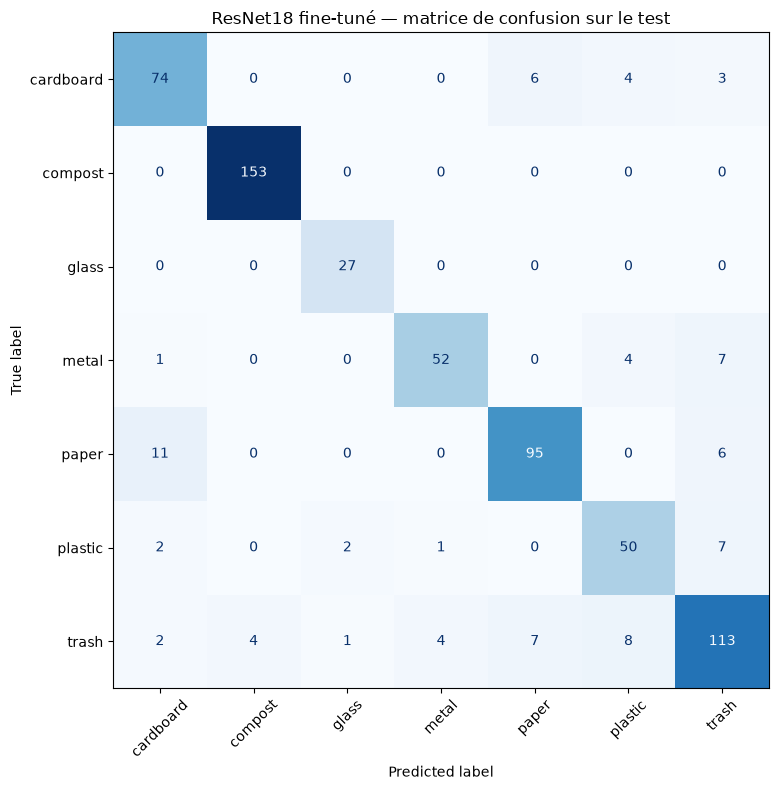

Figure sauvegardée : C:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\outputs\figures\resnet18_finetuned_confusion_matrix.png


In [13]:
confusion = confusion_matrix(
    test_true_labels,
    test_predictions
)

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))

display.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

ax.set_title("ResNet18 fine-tuné — matrice de confusion sur le test")

plt.tight_layout()

figure_path = figures_dir / "resnet18_finetuned_confusion_matrix.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", figure_path)

In [14]:
# Recréation d'un ResNet18 identique puis chargement du meilleur modèle gelé
frozen_model = resnet18(weights=ResNet18_Weights.DEFAULT)

for parameter in frozen_model.parameters():
    parameter.requires_grad = False

frozen_model.fc = nn.Linear(frozen_model.fc.in_features, num_classes)
frozen_model = frozen_model.to(device)

frozen_checkpoint = torch.load(
    resnet_frozen_path,
    map_location=device,
    weights_only=False
)

frozen_model.load_state_dict(frozen_checkpoint["model_state_dict"])
frozen_model.eval()

frozen_true_labels = []
frozen_predictions = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Évaluation ResNet18 gelé"):
        images = images.to(device, non_blocking=True)

        outputs = frozen_model(images)
        predictions = outputs.argmax(dim=1)

        frozen_true_labels.extend(labels.numpy())
        frozen_predictions.extend(predictions.cpu().numpy())

frozen_test_accuracy = np.mean(
    np.array(frozen_true_labels) == np.array(frozen_predictions)
)

frozen_test_macro_f1 = f1_score(
    frozen_true_labels,
    frozen_predictions,
    average="macro",
    zero_division=0
)

print(f"ResNet18 gelé — test accuracy : {frozen_test_accuracy:.4f}")
print(f"ResNet18 gelé — test macro F1 : {frozen_test_macro_f1:.4f}")

Évaluation ResNet18 gelé:   0%|          | 0/21 [00:00<?, ?it/s]

ResNet18 gelé — test accuracy : 0.8432
ResNet18 gelé — test macro F1 : 0.8233


In [16]:
# Recharge les scores sauvegardés dans les checkpoints

resnet_frozen_path = models_dir / "resnet18_frozen_best.pt"
resnet_finetuned_path = models_dir / "resnet18_finetuned_best.pt"

frozen_checkpoint = torch.load(
    resnet_frozen_path,
    map_location=device,
    weights_only=False
)

finetuned_checkpoint = torch.load(
    resnet_finetuned_path,
    map_location=device,
    weights_only=False
)

best_f1_frozen = frozen_checkpoint["best_val_macro_f1"]
best_f1_finetuned = finetuned_checkpoint["best_val_macro_f1"]

print("ResNet18 frozen - meilleur F1 validation :", best_f1_frozen)
print("ResNet18 fine-tuned - meilleur F1 validation :", best_f1_finetuned)

ResNet18 frozen - meilleur F1 validation : 0.8432370869244501
ResNet18 fine-tuned - meilleur F1 validation : 0.857837465387116


In [17]:
comparison_df = pd.DataFrame([
    {
        "model": "SimpleCNN from scratch",
        "trainable_parameters": 423175,
        "best_val_macro_f1": 0.5376,
        "test_accuracy": 0.5062,
        "test_macro_f1": 0.4493
    },
    {
        "model": "ResNet18 frozen",
        "trainable_parameters": 3591,
        "best_val_macro_f1": best_f1_frozen,
        "test_accuracy": frozen_test_accuracy,
        "test_macro_f1": frozen_test_macro_f1
    },
    {
        "model": "ResNet18 fine-tuned",
        "trainable_parameters": finetune_trainable_parameters,
        "best_val_macro_f1": best_f1_finetuned,
        "test_accuracy": resnet_test_accuracy,
        "test_macro_f1": resnet_test_macro_f1
    }
])

comparison_df

,model,trainable_parameters,best_val_macro_f1,test_accuracy,test_macro_f1
0,SimpleCNN from scratch,423175,0.537600,0.506200,0.449300
1,ResNet18 frozen,3591,0.843237,0.843168,0.823341
2,ResNet18 fine-tuned,8397319,0.857837,0.875776,0.870976


In [18]:
comparison_df.to_csv(
    metrics_dir / "model_comparison.csv",
    index=False
)

comparison_df

,model,trainable_parameters,best_val_macro_f1,test_accuracy,test_macro_f1
0,SimpleCNN from scratch,423175,0.537600,0.506200,0.449300
1,ResNet18 frozen,3591,0.843237,0.843168,0.823341
2,ResNet18 fine-tuned,8397319,0.857837,0.875776,0.870976


In [19]:
import hashlib
from PIL import Image

def image_hash(image_path):
    with Image.open(image_path) as image:
        image = image.convert("RGB")
        return hashlib.md5(image.tobytes()).hexdigest()

train_hashes = {}
for path, label in full_train_dataset.samples:
    train_hashes.setdefault(image_hash(path), []).append((path, label))

test_hashes = {}
for path, label in test_dataset.samples:
    test_hashes.setdefault(image_hash(path), []).append((path, label))

duplicate_hashes = set(train_hashes) & set(test_hashes)

print("Nombre de doublons exacts train/test :", len(duplicate_hashes))

c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Nombre de doublons exacts train/test : 105


In [20]:
duplicate_rows = []

for test_index, (test_path, test_label) in enumerate(test_dataset.samples):
    image_id = image_hash(test_path)

    if image_id in train_hashes:
        train_labels_for_image = {
            label for _, label in train_hashes[image_id]
        }

        duplicate_rows.append({
            "test_class": class_names[test_label],
            "train_classes": ", ".join(
                class_names[label]
                for label in sorted(train_labels_for_image)
            ),
            "same_label": test_label in train_labels_for_image
        })

duplicates_df = pd.DataFrame(duplicate_rows)

print("Nombre d'images test dupliquées :", len(duplicates_df))
print("\nDoublons avec le même label :")
print(duplicates_df["same_label"].value_counts())

print("\nRépartition des doublons par classe test :")
display(duplicates_df["test_class"].value_counts())

print("\nCorrespondance des labels train/test :")
display(
    pd.crosstab(
        duplicates_df["test_class"],
        duplicates_df["train_classes"]
    )
)

Nombre d'images test dupliquées : 108

Doublons avec le même label :
same_label
True     100
False      8
Name: count, dtype: int64

Répartition des doublons par classe test :


TypeError: 'ConfusionMatrixDisplay' object is not callable

In [21]:
duplicate_test_indices = []
duplicate_rows = []

for test_index, (test_path, test_label) in enumerate(test_dataset.samples):
    image_id = image_hash(test_path)

    if image_id in train_hashes:
        train_labels_for_image = {
            label for _, label in train_hashes[image_id]
        }

        duplicate_test_indices.append(test_index)

        duplicate_rows.append({
            "test_index": test_index,
            "test_class": class_names[test_label],
            "train_classes": ", ".join(
                class_names[label]
                for label in sorted(train_labels_for_image)
            ),
            "same_label": test_label in train_labels_for_image
        })

duplicates_df = pd.DataFrame(duplicate_rows)

print("Images test dupliquées :", len(duplicates_df))
print("\nMême label :")
print(duplicates_df["same_label"].value_counts().to_string())

print("\nDoublons par classe test :")
print(duplicates_df["test_class"].value_counts().to_string())

print("\nCorrespondance train / test :")
print(
    pd.crosstab(
        duplicates_df["test_class"],
        duplicates_df["train_classes"]
    ).to_string()
)

duplicates_df.to_csv(
    metrics_dir / "exact_duplicates_train_test.csv",
    index=False
)

c:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\.venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Images test dupliquées : 108

Même label :
same_label
True     100
False      8

Doublons par classe test :
test_class
trash        35
compost      22
paper        19
cardboard    13
plastic      12
metal         6
glass         1

Correspondance train / test :
train_classes  cardboard  compost  glass  metal  paper  plastic  plastic, trash  trash
test_class                                                                            
cardboard             12        0      0      0      0        0               0      1
compost                0       22      0      0      0        0               0      0
glass                  0        0      1      0      0        0               0      0
metal                  0        0      0      3      0        1               0      2
paper                  0        0      0      0     17        0               0      2
plastic                0        0      0      0      0       12               0      0
trash                  0        0      0  

In [22]:
from torch.utils.data import Subset, DataLoader

duplicate_test_index_set = set(duplicate_test_indices)

clean_test_indices = [
    index
    for index in range(len(test_dataset))
    if index not in duplicate_test_index_set
]

clean_test_dataset = Subset(test_dataset, clean_test_indices)

clean_test_loader = DataLoader(
    clean_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda")
)

print("Test initial :", len(test_dataset))
print("Images retirées :", len(duplicate_test_index_set))
print("Test propre :", len(clean_test_dataset))

Test initial : 644
Images retirées : 108
Test propre : 536


In [23]:
def evaluate_on_loader(model_to_evaluate, loader):
    model_to_evaluate.eval()

    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Évaluation test propre"):
            images = images.to(device, non_blocking=True)

            outputs = model_to_evaluate(images)
            predictions = outputs.argmax(dim=1)

            true_labels.extend(labels.numpy())
            predicted_labels.extend(predictions.cpu().numpy())

    accuracy = np.mean(
        np.array(true_labels) == np.array(predicted_labels)
    )

    macro_f1 = f1_score(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0
    )

    return accuracy, macro_f1, true_labels, predicted_labels


frozen_clean_accuracy, frozen_clean_f1, _, _ = evaluate_on_loader(
    frozen_model,
    clean_test_loader
)

finetuned_clean_accuracy, finetuned_clean_f1, _, _ = evaluate_on_loader(
    model,
    clean_test_loader
)

print(f"ResNet18 gelé — accuracy test propre : {frozen_clean_accuracy:.4f}")
print(f"ResNet18 gelé — macro F1 test propre : {frozen_clean_f1:.4f}")

print(f"\nResNet18 fine-tuné — accuracy test propre : {finetuned_clean_accuracy:.4f}")
print(f"ResNet18 fine-tuné — macro F1 test propre : {finetuned_clean_f1:.4f}")

Évaluation test propre:   0%|          | 0/17 [00:00<?, ?it/s]

Évaluation test propre:   0%|          | 0/17 [00:00<?, ?it/s]

ResNet18 gelé — accuracy test propre : 0.8563
ResNet18 gelé — macro F1 test propre : 0.8389

ResNet18 fine-tuné — accuracy test propre : 0.8694
ResNet18 fine-tuné — macro F1 test propre : 0.8644


In [24]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, images):
        return self.classifier(self.features(images))


cnn_model = SimpleCNN(num_classes=num_classes).to(device)

cnn_path = models_dir / "cnn_baseline_best.pt"

cnn_checkpoint = torch.load(
    cnn_path,
    map_location=device,
    weights_only=False
)

cnn_model.load_state_dict(cnn_checkpoint["model_state_dict"])
cnn_model.eval()

cnn_clean_accuracy, cnn_clean_f1, _, _ = evaluate_on_loader(
    cnn_model,
    clean_test_loader
)

print(f"CNN baseline — accuracy test propre : {cnn_clean_accuracy:.4f}")
print(f"CNN baseline — macro F1 test propre : {cnn_clean_f1:.4f}")

Évaluation test propre:   0%|          | 0/17 [00:00<?, ?it/s]

CNN baseline — accuracy test propre : 0.5168
CNN baseline — macro F1 test propre : 0.4680


In [25]:
comparison_clean_df = pd.DataFrame([
    {
        "model": "SimpleCNN from scratch",
        "trainable_parameters": 423175,
        "best_val_macro_f1": 0.5376,
        "clean_test_accuracy": cnn_clean_accuracy,
        "clean_test_macro_f1": cnn_clean_f1
    },
    {
        "model": "ResNet18 frozen",
        "trainable_parameters": 3591,
        "best_val_macro_f1": best_f1_frozen,
        "clean_test_accuracy": frozen_clean_accuracy,
        "clean_test_macro_f1": frozen_clean_f1
    },
    {
        "model": "ResNet18 fine-tuned",
        "trainable_parameters": 8397319,
        "best_val_macro_f1": best_f1_finetuned,
        "clean_test_accuracy": finetuned_clean_accuracy,
        "clean_test_macro_f1": finetuned_clean_f1
    }
])

comparison_clean_df.to_csv(
    metrics_dir / "model_comparison_clean_test.csv",
    index=False
)

comparison_clean_df

,model,trainable_parameters,best_val_macro_f1,clean_test_accuracy,clean_test_macro_f1
0,SimpleCNN from scratch,423175,0.537600,0.516791,0.467974
1,ResNet18 frozen,3591,0.843237,0.856343,0.838851
2,ResNet18 fine-tuned,8397319,0.857837,0.869403,0.864435


In [26]:
# Rapport détaillé sur le test propre avec ResNet18 fine-tuné

finetuned_clean_accuracy, finetuned_clean_f1, clean_true_labels, clean_predictions = evaluate_on_loader(
    model,
    clean_test_loader
)

resnet_clean_report = classification_report(
    clean_true_labels,
    clean_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

resnet_clean_report_df = pd.DataFrame(resnet_clean_report).transpose()

resnet_clean_report_df.to_csv(
    metrics_dir / "resnet18_finetuned_clean_classification_report.csv",
    index=True
)

resnet_clean_report_df

Évaluation test propre:   0%|          | 0/17 [00:00<?, ?it/s]

,precision,recall,f1-score,support
cardboard,0.815789,0.837838,0.826667,74.000000
compost,0.970370,1.000000,0.984962,131.000000
glass,0.896552,1.000000,0.945455,26.000000
metal,0.925926,0.862069,0.892857,58.000000
paper,0.865169,0.827957,0.846154,93.000000
plastic,0.750000,0.780000,0.764706,50.000000
trash,0.801980,0.778846,0.790244,104.000000
accuracy,0.869403,0.869403,0.869403,0.869403
macro avg,0.860827,0.869530,0.864435,536.000000
weighted avg,0.869156,0.869403,0.868813,536.000000


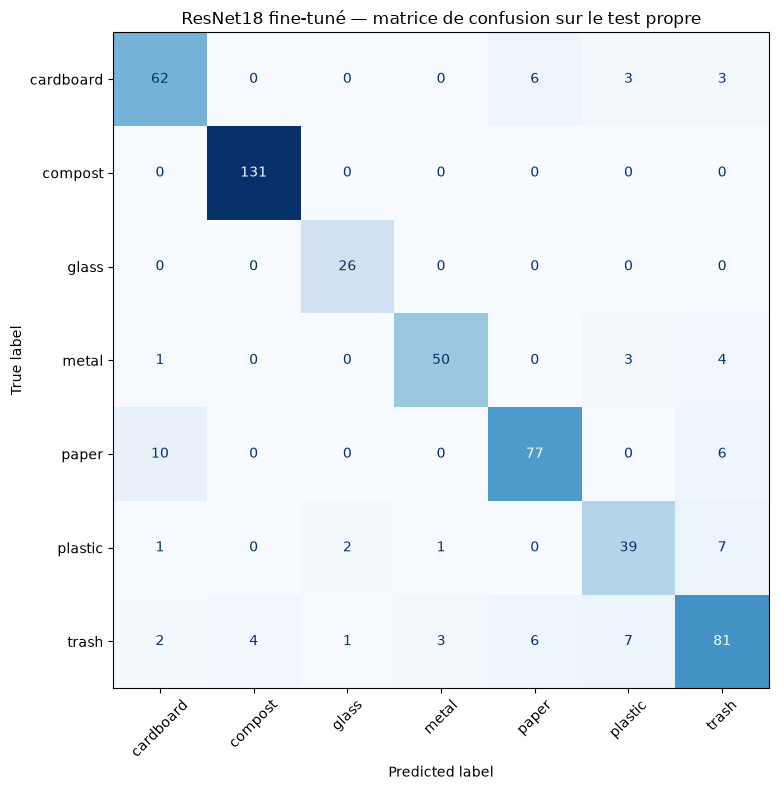

Figure sauvegardée : C:\Users\alid7\OneDrive\Documents\projets\deep-learning-waste-classification\outputs\figures\resnet18_finetuned_clean_confusion_matrix.png


In [27]:
clean_confusion = confusion_matrix(
    clean_true_labels,
    clean_predictions
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=clean_confusion,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 8))

display_matrix.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45,
    colorbar=False
)

ax.set_title("ResNet18 fine-tuné — matrice de confusion sur le test propre")

plt.tight_layout()

figure_path = figures_dir / "resnet18_finetuned_clean_confusion_matrix.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure sauvegardée :", figure_path)